# Pagoda2.1 Multiome Workflow (RNA + ATAC)

This notebook shows the pagoda2.1 **multimodal** workflow on a 10x
Genomics [PBMC granulocyte-sorted 3k
multiome](https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0)
sample, where each cell is measured by both gene expression (RNA) and
chromatin accessibility (ATAC peaks). The public 10x file is
`pbmc_granulocyte_sorted_3k_filtered_feature_bc_matrix.h5`; here it is
in a local folder named `data`.

Each modality is a **facet** with its own normalization view recipe. RNA
uses `plain` (depth-normalize + log1p); ATAC uses `tfidf`
(term-frequency × inverse-document-frequency), reduced by **LSI**
(TF-IDF → SVD, dropping the depth-correlated first component). The two
facets are then integrated with **WNN**, exactly as for CITE-seq — only
the per-facet reductions differ.

## Import into facets

A 10x multiome HDF5 carries both `Gene Expression` and `Peaks` feature
types; pagoda2 splits them into facets automatically.

In [ ]:
h5 <- "data/pbmc_granulocyte_sorted_3k_filtered_feature_bc_matrix.h5"
p2 <- suppressMessages(pagoda2::Pagoda2$from10xH5(h5, verbose = FALSE))

do.call(rbind, lapply(p2$listFacets(), function(f) {
  x <- p2$getFacet(f)
  data.frame(facet = f, model = x$modelType, feature_type = x$featureType,
             features = ncol(x$rawCounts), cells = nrow(x$rawCounts),
             default_reduction = x$defaultReduction)
}))

  facet model feature_type features cells default_reduction
1   RNA plain         gene    36601  2711               PCA
2  ATAC tfidf         peak    98319  2711               LSI

ATAC contributes tens of thousands of peaks; RNA contributes the genes.

## QC

In [ ]:
suppressMessages(invisible(p2$runQC(verbose = FALSE)))
qc <- p2$resolveCellMeta(c("n_molecules", "n_genes", "qc_pass"))
data.frame(cells = nrow(qc),
           median_RNA_molecules = median(qc$n_molecules, na.rm = TRUE),
           median_RNA_genes = median(qc$n_genes, na.rm = TRUE))

  cells median_RNA_molecules median_RNA_genes
1  2711                 3790             1791

## Per-facet reductions: RNA PCA + ATAC LSI

RNA is reduced by PCA on overdispersed genes; ATAC by LSI on its TF-IDF
view. For a quick tutorial we run LSI on the most-accessible peaks; for
a full analysis use all peaks.

In [ ]:
suppressWarnings({
  p2$runVariance(verbose = FALSE)
  p2$runReduction(nPcs = 30, verbose = FALSE)                                   # RNA -> reductions[["PCA"]]
  atac <- p2$getFacet("ATAC")
  top.peaks <- names(sort(Matrix::colSums(atac$rawCounts), decreasing = TRUE))[seq_len(min(20000, ncol(atac$rawCounts)))]
  p2$runReduction(facet = "ATAC", method = "lsi", genes = top.peaks, nPcs = 30, verbose = FALSE) # -> reductions[["ATAC:LSI"]]
})
names(p2$reductions)

[1] "PCA"      "ATAC:LSI"

## WNN integration

`runGraph(method = "wnn")` learns per-cell modality weights and fuses
the RNA and ATAC neighborhoods — the same call as for CITE-seq, now over
`c("RNA", "ATAC")`.

In [ ]:
suppressWarnings(p2$runGraph(method = "wnn", facets = c("RNA", "ATAC"), verbose = FALSE))
data.frame(mean_RNA_weight = round(mean(p2$cellMeta$wnn_weight_RNA, na.rm = TRUE), 3),
           mean_ATAC_weight = round(mean(p2$cellMeta$wnn_weight_ATAC, na.rm = TRUE), 3))

  mean_RNA_weight mean_ATAC_weight
1           0.194            0.806

## Joint clustering and embedding

In [ ]:
suppressWarnings({
  p2$runClustering(graph = "WNN", name = "wnn_leiden")
  p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)
})
data.frame(clusters = length(unique(stats::na.omit(p2$cellMeta$wnn_leiden))))

  clusters
1        7

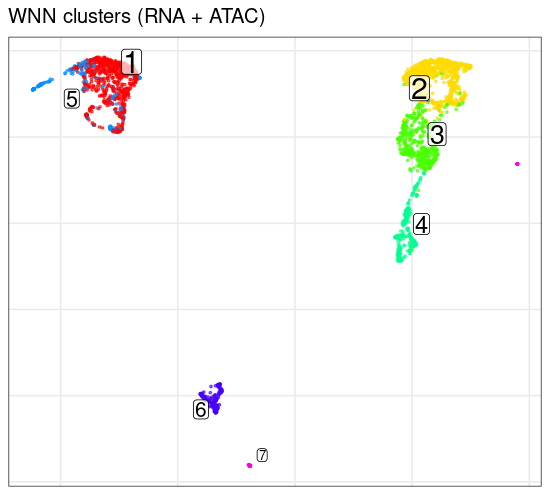

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden",
                 mark.groups = TRUE, size = 0.5, alpha = 0.6, title = "WNN clusters (RNA + ATAC)")

The per-cell ATAC weight shows where chromatin accessibility, rather
than RNA, drives the joint neighborhood structure.

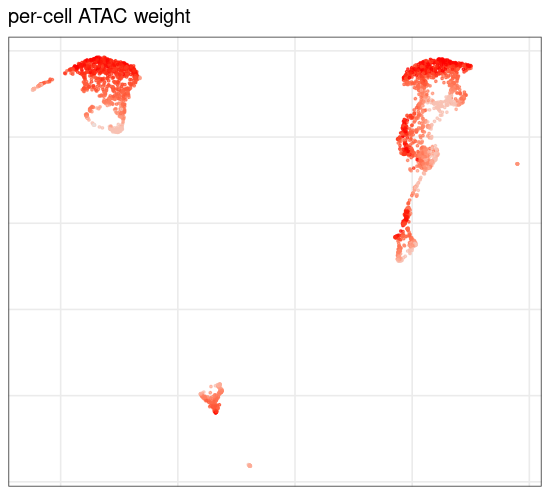

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ATAC, rownames(p2$cellMeta)),
                 size = 0.5, alpha = 0.7, title = "per-cell ATAC weight")

## RNA markers per cluster

Markers are computed on the RNA facet (the interpretable modality); the
joint WNN clusters are annotated from these.

In [ ]:
suppressWarnings(p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE))

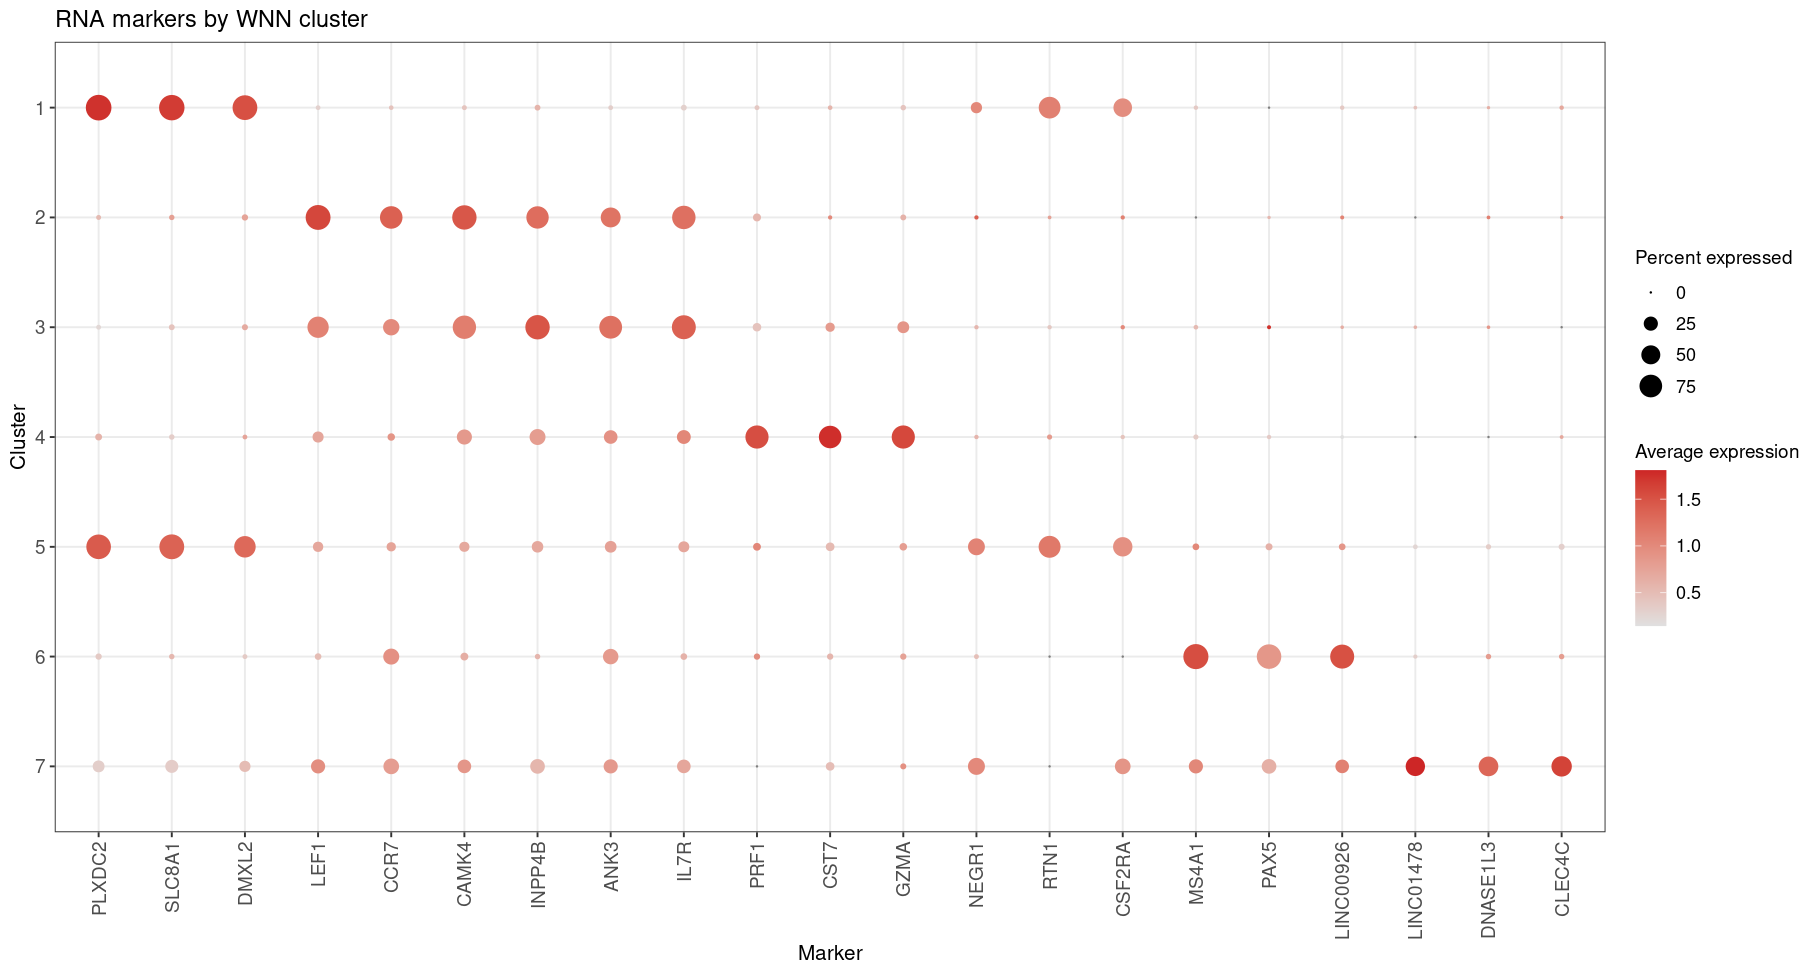

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

Canonical lineage genes on the joint embedding confirm the clusters —
`plotEmbedding(gene = ..., facet = "RNA")` (RNA is the default facet, so
`facet=` is optional here):

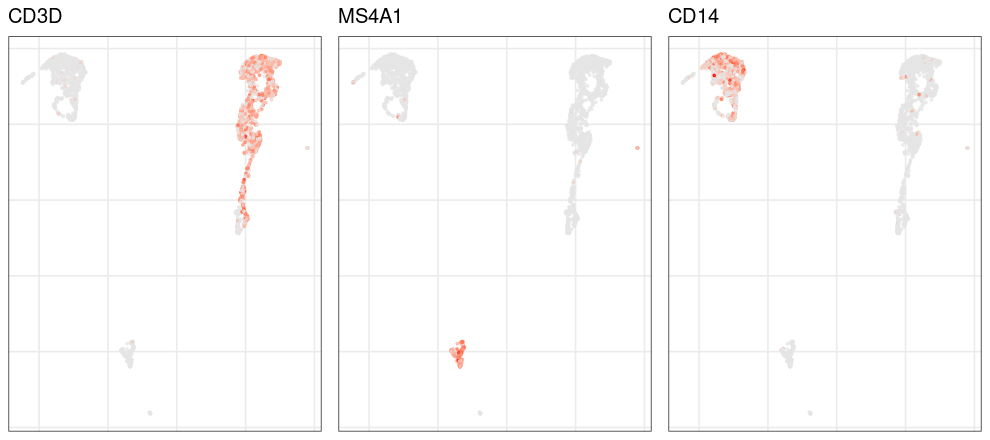

In [ ]:
markers <- intersect(c("CD3D", "MS4A1", "CD14"), pagoda2:::.pagoda2_axis_names(p2, "gene"))
plots <- lapply(markers, function(g)
  p2$plotEmbedding(reduction = "WNN", embedding = "umap", gene = g, facet = "RNA",
                   size = 0.5, alpha = 0.7, title = g))
cowplot::plot_grid(plotlist = plots, nrow = 1)

## Next steps

- **Annotate** the WNN clusters from the RNA markers
  (`p2$annotateClusters(from = "wnn_leiden", ...)`).
- **Reduction-level integration** is also available —
  `p2$runReduction(facets = c("RNA","ATAC"), method = "cca")` (or
  `"concat"`) — though WNN is the usual choice for RNA + ATAC.
- **Scale:** run LSI on all peaks (drop the `genes = top.peaks` subset)
  for a full analysis; the disk-backed `backend = "lstar"` keeps large
  peak matrices out of memory.
- See the [single-dataset](pagoda2.1-single-dataset.ipynb) (RNA) and
  [CITE-seq](pagoda2.1-citeseq.ipynb) (RNA + protein) notebooks for the
  other modalities.